## Feature Engineering

In this section we construct linguistic features capturing lexical simplicity and repetition in song lyrics.  
These features are computed using the tokenized lyrics produced in the preprocessing stage.


In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR  = Path.cwd().parent   # notebooks run from notebooks/ subfolder
RAW       = BASE_DIR / "data" / "raw"
PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS   = BASE_DIR / "outputs"
MODELS    = BASE_DIR / "models"

df = pd.read_pickle(PROCESSED / "lyrics_preprocessed.pkl")
df.columns
df.shape

In [ ]:
# Set to True to re-run all feature engineering even if outputs already exist
FORCE_RECOMPUTE = False

In [2]:
df

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,...,entry_date,exit_date,days_in_top50,lyrics,language,lyrics_length,lyrics_clean,word_count,lyrics_preproc_v2,tokens
0,4KULAymBBJcPRpk1yO4dOG,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",Zach Bryan,2023-08-25,0.429,0.453,0.1550,77.639,-7.746,...,2023-10-18,2025-06-11,603,[Verse 1: Zach Bryan]\nRotgut whiskey's gonna ...,en,1886,rotgut whiskey s gonna ease my mind beach towe...,172,rotgut whiskey gon ease mind beach towel rest ...,"[rotgut, whiskey, gon, ease, mind, beach, towe..."
1,7KA4W4McWYRpgf0fWsJZWB,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",Flower Boy,2017-07-21,0.558,0.559,0.6200,78.558,-9.222,...,2023-10-18,2025-06-11,603,"[Intro: Tyler, The Creator]\nOkay, okay, okay,...",en,2665,okay okay okay okay okay okay o you live in my...,268,okay okay okay okay okay okay live dream state...,"[okay, okay, okay, okay, okay, okay, live, dre..."
2,17phhZDn6oGtzMe56NuWvj,Lose Control,Teddy Swims,I've Tried Everything But Therapy (Part 1),2023-09-15,0.561,0.604,0.2420,159.920,-4.409,...,2023-12-29,2025-06-11,531,[Verse 1]\nSomething's got a hold of me lately...,en,1484,something s got a hold of me lately no i don t...,123,something got hold lately know anymore feel li...,"[something, got, hold, lately, know, anymore, ..."
3,4iZ4pt7kvcaH6Yo8UoZ4s2,Snooze,SZA,SOS,2022-12-09,0.559,0.551,0.3920,143.008,-7.231,...,2023-10-18,2025-03-03,503,[Intro: Leon Thomas III]\nOoh\nI think I know\...,en,2263,ooh i think i know i ll touch that fire for yo...,177,think know touch fire three four time testify ...,"[think, know, touch, fire, three, four, time, ..."
4,1Qrg8KqiBpW07V7PNxwwwL,Kill Bill,SZA,SOS,2022-12-08,0.644,0.735,0.4180,88.980,-5.747,...,2023-10-18,2025-02-14,486,[Verse 1]\nI'm still a fan even though I was s...,en,1762,i m still a fan even though i was salty hate t...,150,still fan even though salty hate see broad kno...,"[still, fan, even, though, salty, hate, see, b..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,11BKm0j4eYoCPPpCONAVwA,Bloody Mary,Lady Gaga,Born This Way (Special Edition),2011-01-01,0.591,0.634,0.4400,99.998,-6.365,...,2024-11-02,2024-11-02,1,[Intro]\nMoney\n\n[Verse 1]\nLove is just a hi...,en,1644,money love is just a history that they may pro...,181,money love history may prove gone tell religio...,"[money, love, history, may, prove, gone, tell,..."
678,6TZTu1F0gnp8mtzvYZao41,The Addams Family,Andrew Gold,Halloween Howls: Fun & Scary Music,1996-01-01,0.898,0.310,0.8810,115.073,-13.578,...,2024-11-02,2024-11-02,1,[Chorus]\nThey're creepy and they're kooky\nMy...,en,505,they re creepy and they re kooky mysterious an...,44,creepy kooky mysterious spooky together ooky a...,"[creepy, kooky, mysterious, spooky, together, ..."
679,6hu1bJBNMeXIepHr1joKW4,Meteor Man,Lil Uzi Vert,Eternal Atake 2,2024-11-01,0.555,0.740,0.0384,134.906,-5.884,...,2024-11-03,2024-11-03,1,[Verse 1]\nTell 'em don't call my phone (Phone...,en,3685,tell em don t call my phone phone call my phon...,458,tell em call phone phone call phone hello even...,"[tell, em, call, phone, phone, call, phone, he..."
680,0F60WLPs6Oz2slHomvLt9U,We Good,Lil Uzi Vert,Eternal Atake 2,2024-11-01,0.587,0.800,0.8230,144.332,-3.194,...,2024-11-03,2024-11-03,1,"[Intro]\nEA 2\nEA 2\nWoah\n\n[Chorus]\nYeah, n...",en,1952,ea ea woah yeah new contract i read mines huh ...,215,ea ea new contract read mine said lost thought...,"[ea, ea, new, contract, read, mine, said, lost..."


### Simplicity and repetition feature functions

In [3]:
def type_token_ratio(tokens):
    
    if len(tokens) == 0:
        return 0
    
    return len(set(tokens)) / len(tokens)


def avg_word_length(tokens):
    
    if len(tokens) == 0:
        return 0
    
    return np.mean([len(word) for word in tokens])


def repetition_ratio(tokens):
    
    if len(tokens) == 0:
        return 0
    
    counts = Counter(tokens)
    
    most_common_count = counts.most_common(1)[0][1]
    
    return most_common_count / len(tokens)


def max_word_frequency(tokens):
    
    if len(tokens) == 0:
        return 0
    
    counts = Counter(tokens)
    
    return counts.most_common(1)[0][1]


def bigram_repetition_ratio(tokens):
    
    if len(tokens) < 2:
        return 0
    
    bigrams = list(zip(tokens[:-1], tokens[1:]))
    
    counts = Counter(bigrams)
    
    most_common_count = counts.most_common(1)[0][1]
    
    return most_common_count / len(bigrams)



#### Apply functions to the dataset

In [4]:
df["ttr"] = df["tokens"].apply(type_token_ratio)

df["avg_word_length"] = df["tokens"].apply(avg_word_length)

df["repetition_ratio"] = df["tokens"].apply(repetition_ratio)

df["max_word_freq"] = df["tokens"].apply(max_word_frequency)

df["bigram_repetition_ratio"] = df["tokens"].apply(bigram_repetition_ratio)


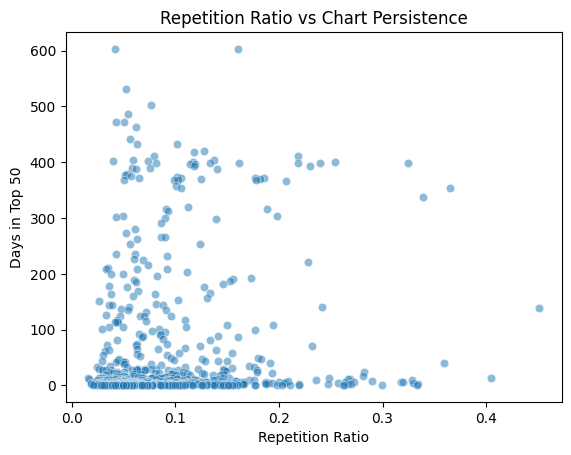

In [5]:
plt.figure()

sns.scatterplot(
    x=df["repetition_ratio"],
    y=df["days_in_top50"],
    alpha=0.5
)

plt.title("Repetition Ratio vs Chart Persistence")
plt.xlabel("Repetition Ratio")
plt.ylabel("Days in Top 50")

plt.show()


#### Inspect results

In [6]:
df[[
    "tokens",
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "bigram_repetition_ratio"
]].head(20)


,tokens,ttr,avg_word_length,repetition_ratio,max_word_freq,bigram_repetition_ratio
0,"[rotgut, whiskey, gon, ease, mind, beach, towe...",0.467456,5.011834,0.041420,7,0.017857
1,"[okay, okay, okay, okay, okay, okay, live, dre...",0.394495,4.527523,0.160550,35,0.147465
2,"[something, got, hold, lately, know, anymore, ...",0.587719,4.798246,0.052632,6,0.053097
3,"[think, know, touch, fire, three, four, time, ...",0.461988,4.807018,0.076023,13,0.058824
4,"[still, fan, even, though, salty, hate, see, b...",0.459459,4.594595,0.054054,8,0.027211
5,"[promised, mile, combined, must, change, heart...",0.582822,5.092025,0.042945,7,0.018519
6,"[man, want, world, hand, hate, beach, stand, c...",0.568345,4.676259,0.050360,7,0.043478
7,"[nigga, tryna, get, bish, bish, bish, hit, hou...",0.410802,4.649755,0.062193,38,0.039344
8,"[fine, dusk, light, tellin, baby, thing, eat, ...",0.635514,4.897196,0.056075,6,0.037736
9,"[fine, cool, say, nothing, know, truth, guess,...",0.286920,4.430380,0.101266,24,0.101695


In [7]:
df.columns

Index(['spotify_id', 'name', 'artists', 'album_name', 'album_release_date',
       'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'entry_date', 'exit_date',
       'days_in_top50', 'lyrics', 'language', 'lyrics_length', 'lyrics_clean',
       'word_count', 'lyrics_preproc_v2', 'tokens', 'ttr', 'avg_word_length',
       'repetition_ratio', 'max_word_freq', 'bigram_repetition_ratio'],
      dtype='str')

In [8]:
df[[
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "bigram_repetition_ratio",
    "max_word_freq",
]].describe()

,ttr,avg_word_length,repetition_ratio,bigram_repetition_ratio,max_word_freq
count,682.000000,682.000000,682.000000,682.000000,682.000000
mean,0.519095,4.800162,0.092782,0.060303,17.359238
std,0.140225,0.396159,0.064006,0.049841,13.771205
min,0.084615,3.615385,0.015823,0.004184,1.000000
25%,0.428519,4.550036,0.049180,0.027566,8.000000
50%,0.510527,4.761704,0.073869,0.044693,13.000000
75%,0.620512,5.003205,0.114286,0.076190,21.000000
max,1.000000,6.342857,0.451220,0.361963,95.000000


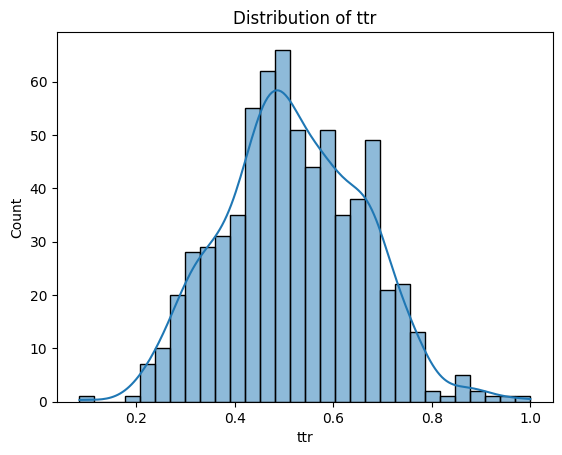

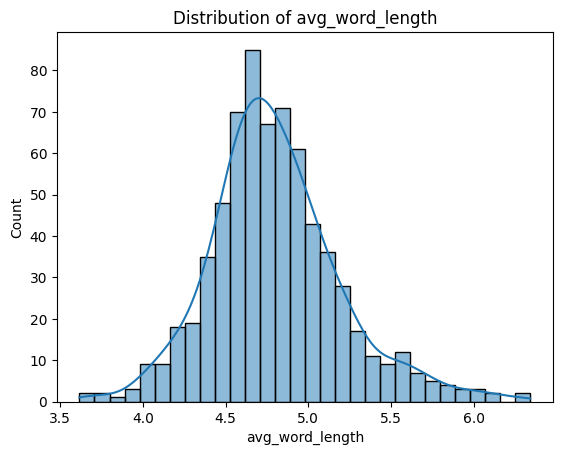

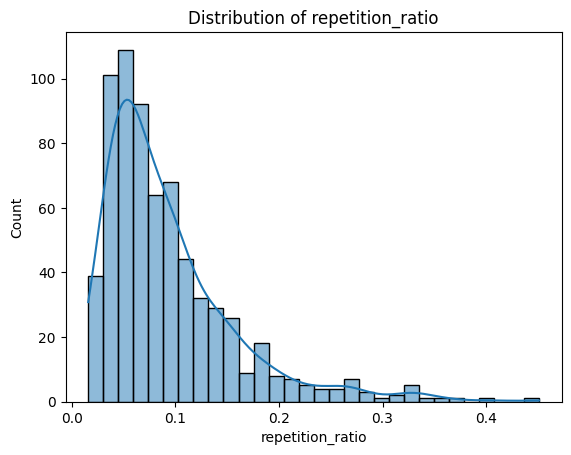

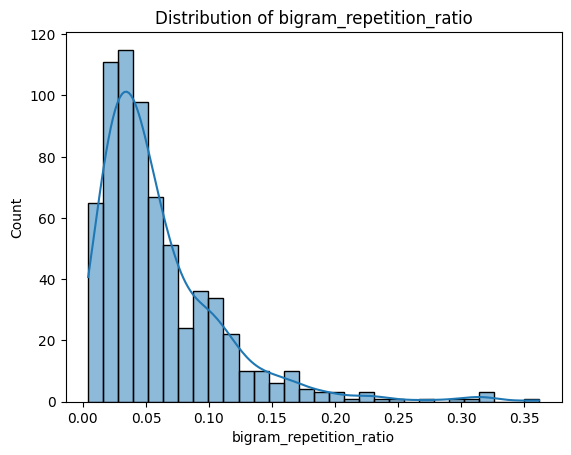

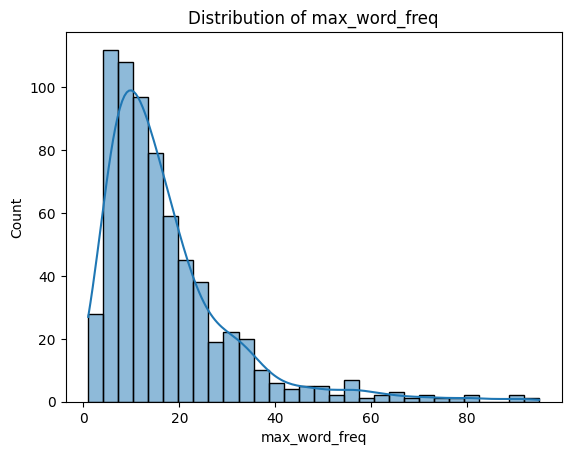

In [9]:
features = [
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "bigram_repetition_ratio",
    "max_word_freq",
]

for f in features:
    plt.figure()
    sns.histplot(df[f], bins=30, kde=True)
    plt.title(f"Distribution of {f}")
    plt.show()


In [10]:
df[[
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "bigram_repetition_ratio",
    "max_word_freq",
]].corr()


,ttr,avg_word_length,repetition_ratio,bigram_repetition_ratio,max_word_freq
ttr,1.000000,0.291672,-0.506224,-0.486361,-0.514402
avg_word_length,0.291672,1.000000,-0.123575,-0.138640,-0.257978
repetition_ratio,-0.506224,-0.123575,1.000000,0.886140,0.713126
bigram_repetition_ratio,-0.486361,-0.138640,0.886140,1.000000,0.621334
max_word_freq,-0.514402,-0.257978,0.713126,0.621334,1.000000


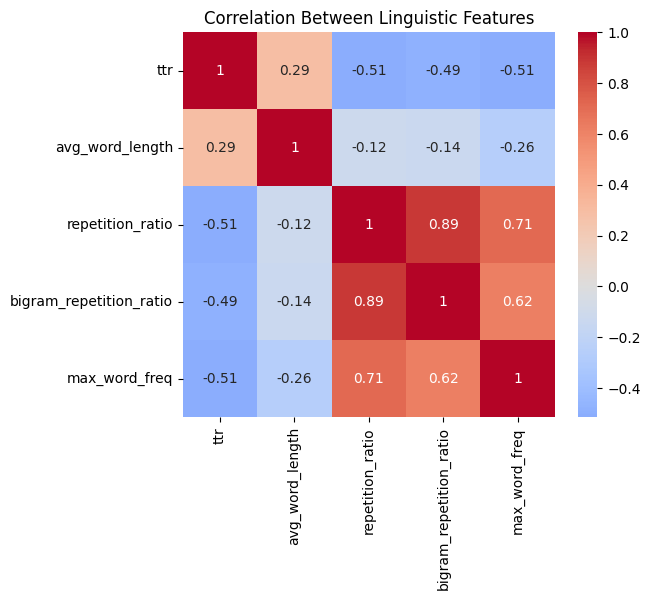

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    df[[
        "ttr",
        "avg_word_length",
        "repetition_ratio",
        "bigram_repetition_ratio",
        "max_word_freq",
    ]].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Linguistic Features")
plt.show()


### Sentiment function

In [12]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def sentiment_features(text):
    
    scores = sia.polarity_scores(text)
    
    polarity = scores["compound"]
    
    intensity = abs(polarity)
    
    return polarity, intensity



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/yaz/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


#### Apply sentiment function to dataset

In [13]:
df[["sentiment_polarity", "sentiment_intensity"]] = df["lyrics_preproc_v2"].apply(
    lambda x: pd.Series(sentiment_features(x))
)


#### Inspect results

In [14]:
df[[
    "tokens",
    "sentiment_polarity",
    "sentiment_intensity"
]].head(20)


,tokens,sentiment_polarity,sentiment_intensity
0,"[rotgut, whiskey, gon, ease, mind, beach, towe...",0.9118,0.9118
1,"[okay, okay, okay, okay, okay, okay, live, dre...",0.9153,0.9153
2,"[something, got, hold, lately, know, anymore, ...",-0.9779,0.9779
3,"[think, know, touch, fire, three, four, time, ...",-0.9764,0.9764
4,"[still, fan, even, though, salty, hate, see, b...",0.9100,0.9100
5,"[promised, mile, combined, must, change, heart...",0.9274,0.9274
6,"[man, want, world, hand, hate, beach, stand, c...",0.9935,0.9935
7,"[nigga, tryna, get, bish, bish, bish, hit, hou...",-0.5305,0.5305
8,"[fine, dusk, light, tellin, baby, thing, eat, ...",-0.9866,0.9866
9,"[fine, cool, say, nothing, know, truth, guess,...",0.9993,0.9993


In [15]:
df[["sentiment_polarity","sentiment_intensity"]].describe()


,sentiment_polarity,sentiment_intensity
count,682.000000,682.000000
mean,0.146113,0.886952
std,0.900626,0.211351
min,-0.999800,0.000000
25%,-0.954775,0.910000
50%,0.781400,0.980100
75%,0.984375,0.993575
max,0.999900,0.999900


## Correlation of linguistic features and chart persistence

In [ ]:
linguistic_cols = [
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "bigram_repetition_ratio",
    "sentiment_polarity",
    "max_word_freq"
]

corr_with_persistence = df[linguistic_cols + ["days_in_top50"]].corr()["days_in_top50"].drop("days_in_top50")

# ── Plot ────────────────────────────────────────────────────
palette = ["#2D6A9F", "#3AA5A0", "#5CB85C", "#E07B39", "#9B59B6"]

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.barh(
    corr_with_persistence.sort_values().index,
    corr_with_persistence.sort_values().values,
    color=palette
)

axes.set_title(
    "Correlation of Linguistic Features with Chart Persistence",
    fontweight="bold",
    fontsize=13
)
axes.set_xlabel("Correlation with Days in Top 50")
axes.set_ylabel("")

# ── Clean spines only, keep background ───────────────────────
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(OUTPUTS / "correlation_linguistic.png", dpi=300, bbox_inches="tight")
plt.show()

## TF-IDF

In [56]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=6,
    max_df=0.6,
    max_features=5000,
)

tfidf_matrix = tfidf.fit_transform(df["lyrics_preproc_v2"])
tfidf_matrix.shape



(682, 2638)

In [18]:
# Inspecting TF-IDF features
feature_names = tfidf.get_feature_names_out()
feature_names[:20]


array(['abandoned', 'account', 'ace', 'across', 'act', 'act like',
       'actin', 'actin like', 'action', 'actually', 'add', 'addict',
       'addicted', 'addiction', 'address', 'admit', 'adore', 'advance',
       'afford', 'afraid'], dtype=object)

In [19]:
"like" in tfidf.get_feature_names_out()

False

In [20]:
# Convert TF-IDF matrix to DataFrame for easier analysis

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=df.index
)

tfidf_df.head(20)

,abandoned,account,ace,across,act,act like,actin,actin like,action,actually,...,yet,yo,york,young,young metro,young nigga,younger,yup,zero,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.041616,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.072980,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# Sanity check: confirm roew order is preserved
print(df.index.equals(tfidf_df.index))
print(df.loc[0, "lyrics_preproc_v2"][:100])


True
rotgut whiskey gon ease mind beach towel rest dryin line remind daddy ford labrador hangin passenger


In [22]:
# Keep IDs separately (not used as model features)
song_ids = df["spotify_id"]

# Select engineered features for scaling and combination with TF-IDF features

engineered_features = df[[
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "sentiment_polarity"
]]

# Scale engineered features before combining with TF-IDF features

scaler = StandardScaler()
engineered_scaled = scaler.fit_transform(engineered_features)

# Convert scaled engineered features back to DataFrame for combination
engineered_scaled_df = pd.DataFrame(
    engineered_scaled,
    columns=engineered_features.columns,
    index=df.index
)

# Combine scaled engineered features with TF-IDF features for modeling
X = pd.concat(
    [
        engineered_scaled_df,
        tfidf_df
    ],
    axis=1
)

X.describe()



,ttr,avg_word_length,repetition_ratio,max_word_freq,sentiment_polarity,abandoned,account,ace,across,act,...,yet,yo,york,young,young metro,young nigga,younger,yup,zero,zone
count,6.820000e+02,6.820000e+02,6.820000e+02,6.820000e+02,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,...,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000
mean,-2.083703e-17,7.143194e-16,7.292961e-17,-7.813886e-18,0.000000,0.000849,0.000718,0.000647,0.002821,0.002787,...,0.004431,0.002539,0.001771,0.006586,0.001363,0.000972,0.000939,0.000936,0.001085,0.001062
std,1.000734e+00,1.000734e+00,1.000734e+00,1.000734e+00,1.000734,0.010112,0.006676,0.006827,0.016227,0.013747,...,0.035947,0.013802,0.022933,0.025848,0.017779,0.007169,0.011270,0.010066,0.010613,0.010156
min,-3.100723e+00,-2.992860e+00,-1.203259e+00,-1.188803e+00,-1.273285,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.464106e-01,-6.318433e-01,-6.817145e-01,-6.801225e-01,-1.223255,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-6.114510e-02,-9.714981e-02,-2.957095e-01,-3.167796e-01,0.705901,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.237760e-01,5.129053e-01,3.362063e-01,2.645690e-01,0.931438,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.432040e+00,3.896993e+00,5.604157e+00,5.642044e+00,0.948688,0.170438,0.096511,0.108447,0.199592,0.141347,...,0.714754,0.167952,0.540649,0.254123,0.395843,0.102448,0.216105,0.174423,0.165319,0.164426


In [23]:
engineered_scaled_df.columns

Index(['ttr', 'avg_word_length', 'repetition_ratio', 'max_word_freq',
       'sentiment_polarity'],
      dtype='str')

In [24]:
# Final feature set ready for modeling
X.head()

,ttr,avg_word_length,repetition_ratio,max_word_freq,sentiment_polarity,abandoned,account,ace,across,act,...,yet,yo,york,young,young metro,young nigga,younger,yup,zero,zone
0,-0.368533,0.534703,-0.803045,-0.752791,0.850796,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.889223,-0.688713,1.059554,1.281929,0.854685,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.489744,-0.004842,-0.627754,-0.825460,-1.248951,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.407551,0.017317,-0.262024,-0.316780,-1.247284,0.0,0.0,0.0,0.0,0.0,...,0.041616,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.425599,-0.519284,-0.605514,-0.680123,0.848796,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
# Top TF-IDF terms

import numpy as np

# compute average TF-IDF score for each term
tfidf_means = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# create dataframe
tfidf_summary = pd.DataFrame({
    "term": tfidf.get_feature_names_out(),
    "avg_tfidf": tfidf_means
})

# sort by importance
top_terms = tfidf_summary.sort_values(by="avg_tfidf", ascending=False)

top_terms.head(10)


,term,avg_tfidf
1544,nigga,0.036703
1358,love,0.035866
832,get,0.032707
83,baby,0.028321
172,bitch,0.027586
1602,one,0.027393
878,go,0.025527
1245,let,0.025356
2008,shit,0.025157
796,fuck,0.024014


In [ ]:
import matplotlib.pyplot as plt

# ── Prepare data ────────────────────────────────────────────
df_display = top_terms.head(10).reset_index(drop=True).copy()
df_display["avg_tfidf"] = df_display["avg_tfidf"].round(4)

# ── Create figure ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")

table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    loc="center",
    cellLoc="center"
)

# ── Styling ────────────────────────────────────────────────
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#3AA5A0")  # header
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("none")     # transparent rows
        cell.set_text_props(color="black")

# Adjust size
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

# Title (optional — remove if you want only the table in Canva)
plt.title("Top TF-IDF Terms", fontsize=12, fontweight="bold")

# ── Save with transparent background ───────────────────────
plt.savefig(
    OUTPUTS / "top_tfidf_table.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [ ]:
_output_path = PROCESSED / "features_extracted.pkl"

if not FORCE_RECOMPUTE and _output_path.exists():
    X = pd.read_pickle(_output_path)
    print("Loaded from cache:", _output_path)
else:
    X.to_pickle(PROCESSED / "features_extracted.pkl")
    X.to_csv(PROCESSED / "features_extracted.csv", index=False)
    print("Saved to:", PROCESSED)

## Create target variable

In [27]:
# Calculate average duration in top 50
avg_duration= df["days_in_top50"].mean()
print(avg_duration)

# Calculate median duration in top 50
median_duration = df["days_in_top50"].median()
print(median_duration)

63.961876832844574
8.0


In [ ]:
_target_path = PROCESSED / "target_variable.csv"

if not FORCE_RECOMPUTE and _target_path.exists():
    y = pd.read_csv(_target_path).squeeze()
    print("Loaded target from cache:", _target_path)
else:
    # Create binary target variable using a 60-day threshold
    threshold = 60
    df = df.copy()
    df["long_chart"] = (df["days_in_top50"] > threshold).astype(int)
    y = df["long_chart"]
    y.to_csv(PROCESSED / "target_variable.csv", index=False)
    X = df.drop(columns=["days_in_top50", "long_chart"])
    print(y.value_counts(normalize=True))

In [29]:
print(X.shape, y.shape)

(682, 29) (682,)
